In [2]:
# Cell 1: Imports and paths
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

RESULTS_DIR   = Path("../results/processed")
PLOTS_DIR     = Path("../results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load scored results
t4_df   = pd.read_csv(RESULTS_DIR / "T4_scored.csv")
groq_df = pd.read_csv(RESULTS_DIR / "Groq_LPU_Llama_scored.csv")

# Add hardware label if not present
t4_df["hardware"]   = "T4"
groq_df["hardware"] = "Groq"

combined = pd.concat([t4_df, groq_df], ignore_index=True)

print("T4 rows:",   len(t4_df))
print("Groq rows:", len(groq_df))
print("Combined:",  len(combined))

T4 rows: 100
Groq rows: 100
Combined: 200


In [3]:
# Cell 2: Wilson CI helper
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return 0, 0
    p = successes / n
    center = (p + z**2 / (2*n)) / (1 + z**2 / n)
    margin = (z * ((p*(1-p)/n + z**2/(4*n**2))**0.5)) / (1 + z**2/n)
    return center - margin, center + margin

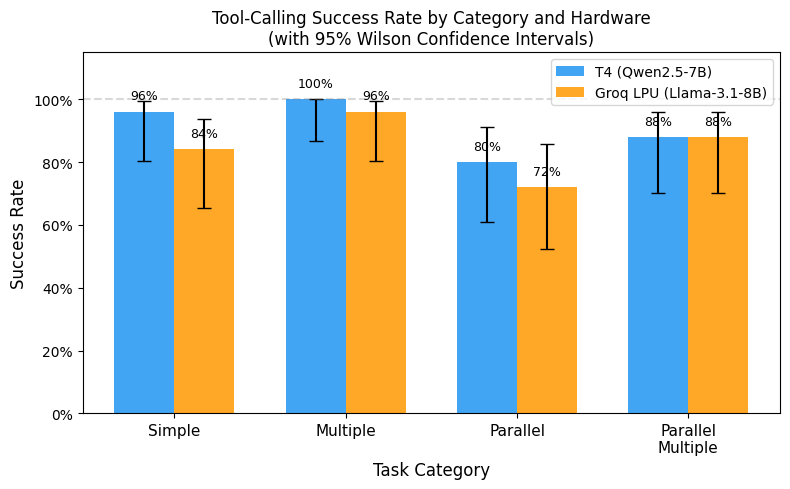

Saved Figure 1


In [4]:
# Cell 3: Figure 1 — Correctness by category with Wilson CI error bars
categories = ["simple", "multiple", "parallel", "parallel_multiple"]
cat_labels  = ["Simple", "Multiple", "Parallel", "Parallel\nMultiple"]

t4_rates, t4_lo, t4_hi     = [], [], []
groq_rates, groq_lo, groq_hi = [], [], []

for cat in categories:
    for rates, lo_list, hi_list, df in [
        (t4_rates,   t4_lo,   t4_hi,   t4_df),
        (groq_rates, groq_lo, groq_hi, groq_df)
    ]:
        sub = df[df["category"] == cat]
        n   = len(sub)
        s   = sub["correct"].sum()
        r   = s / n
        lo, hi = wilson_ci(s, n)
        rates.append(r)
        lo_list.append(r - lo)
        hi_list.append(hi - r)

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, t4_rates, width,
               label="T4 (Qwen2.5-7B)",
               color="#2196F3", alpha=0.85,
               yerr=[t4_lo, t4_hi], capsize=5,
               error_kw={"elinewidth": 1.5})

bars2 = ax.bar(x + width/2, groq_rates, width,
               label="Groq LPU (Llama-3.1-8B)",
               color="#FF9800", alpha=0.85,
               yerr=[groq_lo, groq_hi], capsize=5,
               error_kw={"elinewidth": 1.5})

ax.set_xlabel("Task Category", fontsize=12)
ax.set_ylabel("Success Rate", fontsize=12)
ax.set_title("Tool-Calling Success Rate by Category and Hardware\n(with 95% Wilson Confidence Intervals)",
             fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Annotate bars with values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f"{bar.get_height():.0%}",
            ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f"{bar.get_height():.0%}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig1_correctness_by_category.pdf",
            bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig1_correctness_by_category.png",
            bbox_inches="tight", dpi=300)
plt.show()
print("Saved Figure 1")

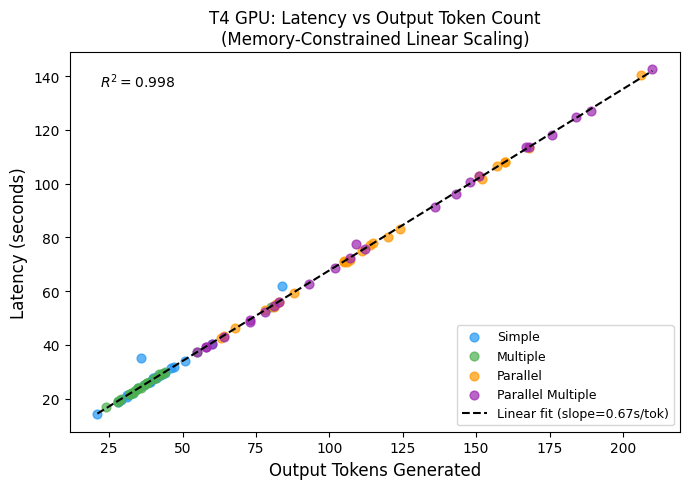

Saved Figure 2 — R²=0.998, slope=0.675s/tok


In [5]:
# Cell 4: Figure 2 — T4 output tokens vs latency scatter with regression
t4_valid = t4_df[t4_df["latency_s"].notna() & t4_df["output_tokens"].notna()].copy()
t4_valid["output_tokens"] = pd.to_numeric(t4_valid["output_tokens"], errors="coerce")
t4_valid["latency_s"]     = pd.to_numeric(t4_valid["latency_s"],     errors="coerce")
t4_valid = t4_valid.dropna(subset=["output_tokens", "latency_s"])

# Color by category
cat_colors = {
    "simple":            "#2196F3",
    "multiple":          "#4CAF50",
    "parallel":          "#FF9800",
    "parallel_multiple": "#9C27B0"
}

fig, ax = plt.subplots(figsize=(7, 5))

for cat, color in cat_colors.items():
    sub = t4_valid[t4_valid["category"] == cat]
    ax.scatter(sub["output_tokens"], sub["latency_s"],
               c=color, alpha=0.7, s=40,
               label=cat.replace("_", " ").title())

# Linear regression
x_vals = t4_valid["output_tokens"].values
y_vals = t4_valid["latency_s"].values
m, b   = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, m * x_line + b,
        color="black", linewidth=1.5, linestyle="--",
        label=f"Linear fit (slope={m:.2f}s/tok)")

r2 = np.corrcoef(x_vals, y_vals)[0, 1]**2
ax.text(0.05, 0.95, f"$R^2 = {r2:.3f}$",
        transform=ax.transAxes, fontsize=10,
        verticalalignment="top")

ax.set_xlabel("Output Tokens Generated", fontsize=12)
ax.set_ylabel("Latency (seconds)", fontsize=12)
ax.set_title("T4 GPU: Latency vs Output Token Count\n(Memory-Constrained Linear Scaling)",
             fontsize=12)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig2_t4_tokens_vs_latency.pdf",
            bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig2_t4_tokens_vs_latency.png",
            bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved Figure 2 — R²={r2:.3f}, slope={m:.3f}s/tok")

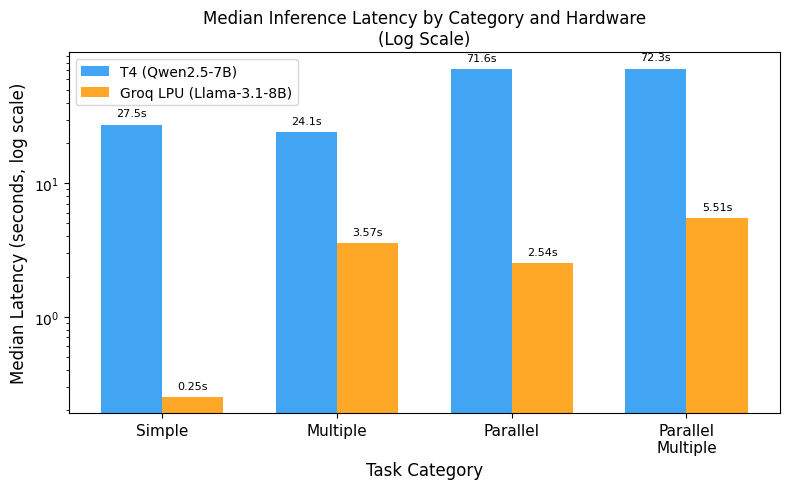

Saved Figure 3


In [6]:
# Cell 5: Figure 3 — Median latency comparison (log scale)
cat_order  = ["simple", "multiple", "parallel", "parallel_multiple"]
cat_labels = ["Simple", "Multiple", "Parallel", "Parallel\nMultiple"]

t4_med   = [t4_df[t4_df["category"]==c]["latency_s"].median()   for c in cat_order]
groq_med = [groq_df[groq_df["category"]==c]["latency_s"].median() for c in cat_order]

x     = np.arange(len(cat_order))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, t4_med,   width,
       label="T4 (Qwen2.5-7B)",
       color="#2196F3", alpha=0.85)
ax.bar(x + width/2, groq_med, width,
       label="Groq LPU (Llama-3.1-8B)",
       color="#FF9800", alpha=0.85)

ax.set_yscale("log")
ax.set_xlabel("Task Category", fontsize=12)
ax.set_ylabel("Median Latency (seconds, log scale)", fontsize=12)
ax.set_title("Median Inference Latency by Category and Hardware\n(Log Scale)",
             fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels, fontsize=11)
ax.legend(fontsize=10)

# Annotate with actual values
for i, (t, g) in enumerate(zip(t4_med, groq_med)):
    ax.text(i - width/2, t * 1.15, f"{t:.1f}s",
            ha="center", fontsize=8)
    ax.text(i + width/2, g * 1.15, f"{g:.2f}s",
            ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig3_latency_comparison.pdf",
            bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig3_latency_comparison.png",
            bbox_inches="tight", dpi=300)
plt.show()
print("Saved Figure 3")

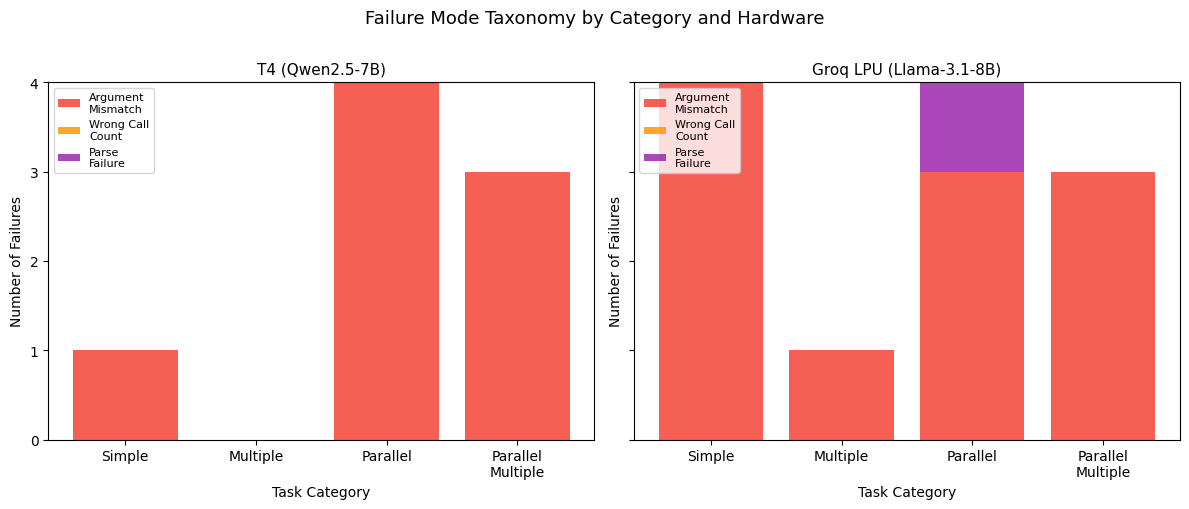

Saved Figure 4


In [7]:
# Cell 6: Figure 4 — Failure taxonomy stacked bar
failure_types = ["argument_mismatch", "wrong_call_count", "parse_failure"]
failure_labels = ["Argument\nMismatch", "Wrong Call\nCount", "Parse\nFailure"]
colors = ["#F44336", "#FF9800", "#9C27B0"]

def get_failure_counts(df, categories):
    counts = {}
    failures = df[df["correct"] == False].copy()
    for cat in categories:
        sub = failures[failures["category"] == cat]
        cat_counts = []
        for ft in failure_types:
            n = sub["score_reason"].str.contains(
                ft.replace("_", " "), case=False, na=False
            ).sum()
            # fallback mapping
            if ft == "argument_mismatch":
                n = sub["score_reason"].str.contains(
                    "Argument mismatch|Missing argument",
                    case=False, na=False
                ).sum()
            elif ft == "wrong_call_count":
                n = sub["score_reason"].str.contains(
                    "Wrong number",
                    case=False, na=False
                ).sum()
            elif ft == "parse_failure":
                n = sub["score_reason"].str.contains(
                    "parse|Could not",
                    case=False, na=False
                ).sum()
            cat_counts.append(n)
        counts[cat] = cat_counts
    return counts

t4_failures   = get_failure_counts(t4_df,   cat_order)
groq_failures = get_failure_counts(groq_df, cat_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, failures, hw_label in [
    (axes[0], t4_failures,   "T4 (Qwen2.5-7B)"),
    (axes[1], groq_failures, "Groq LPU (Llama-3.1-8B)")
]:
    bottoms = np.zeros(len(cat_order))
    for j, (ft, color) in enumerate(zip(failure_types, colors)):
        vals = [failures[c][j] for c in cat_order]
        ax.bar(cat_labels, vals, bottom=bottoms,
               color=color, alpha=0.85,
               label=failure_labels[j])
        bottoms += np.array(vals)

    ax.set_title(hw_label, fontsize=11)
    ax.set_xlabel("Task Category", fontsize=10)
    ax.set_ylabel("Number of Failures", fontsize=10)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

fig.suptitle("Failure Mode Taxonomy by Category and Hardware",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig4_failure_taxonomy.pdf",
            bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig4_failure_taxonomy.png",
            bbox_inches="tight", dpi=300)
plt.show()
print("Saved Figure 4")

In [8]:
# Cell 7: Print summary stats for paper verification
print("=== T4 SUMMARY ===")
print(t4_df.groupby("category")[["latency_s","output_tokens","tokens_per_second"]].mean().round(2))
print("\n=== GROQ SUMMARY ===")
print(groq_df.groupby("category")[["latency_s","output_tokens","tokens_per_second"]].mean().round(2))
print(f"\nAll plots saved to: {PLOTS_DIR.resolve()}")

=== T4 SUMMARY ===
                   latency_s  output_tokens  tokens_per_second
category                                                      
multiple               25.82          38.00               1.47
parallel               76.93         113.96               1.48
parallel_multiple      77.88         115.12               1.48
simple                 27.98          40.52               1.46

=== GROQ SUMMARY ===
                   latency_s  output_tokens  tokens_per_second
category                                                      
multiple                3.83          42.76              12.23
parallel                2.78         123.24              69.58
parallel_multiple       6.05         122.72              30.03
simple                  0.49          45.00             162.06

All plots saved to: /Users/joe/coding/CSE188/BFCL-hardware-efficiency-study/results/plots
